# Baseline Holt-Winters (Benchmark)

This is a Holt-Winters benchmark per zone on top-demand zones.

- Data extraction from HDFS is distributed by Spark.
- Model fitting itself is done in pandas/statsmodels on driver as a benchmark.
- Outputs are written to HDFS 

Time window behavior:
- Auto-detects available min/max timestamp from dense input by default.
- Optionally set WINDOW_START_TS and WINDOW_END_TS to limit the window.

In [1]:
import json
import os
import subprocess
import sys
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

spark = (
    SparkSession.builder
    .appName("DemandPredictionHoltWintersBenchmark_VirtualCluster")
    .master("spark://master:7077")
    .config("spark.eventLog.enabled", "true")
    .config("spark.eventLog.dir", "hdfs://master:9000/spark-logs")
    .config("spark.driver.memory", "1500m")
    .config("spark.driver.memoryOverhead", "512m")
    .config("spark.executor.memory", "2g")
    .config("spark.executor.memoryOverhead", "512m")
    .config("spark.executor.cores", "2")
    .config("spark.cores.max", "6")
    .config("spark.sql.shuffle.partitions", "24")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

def cluster_util(stage_name):
    import json as _json, urllib.request
    print(f"===== CLUSTER UTILIZATION: {stage_name} =====")
    print("Spark master:", spark.sparkContext.master)
    try:
        info = _json.load(urllib.request.urlopen("http://master:8080/json/"))
        workers = info.get("workers", [])
        alive = [w for w in workers if w.get("state") == "ALIVE"]
        apps = info.get("activeapps", [])
        print("alive workers:", len(alive))
        print("active apps :", len(apps))
        for w in alive:
            print("worker", w.get("id"),
                  "cores", f"{w.get('coresused',0)}/{w.get('cores',0)}",
                  "mem(MB)", f"{w.get('memoryused',0)}/{w.get('memory',0)}")
    except Exception as e:
        print("Could not query Spark Standalone Master:", e)


cluster_util("session_started")



:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-39e1d988-16ed-471c-abf6-2152a6d35ec9;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 99ms :: artifacts dl 3ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	------------------------------------------------

===== CLUSTER UTILIZATION: session_started =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260429081424-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429081516-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429081424-172.18.0.3-7078 cores 2/2 mem(MB) 2048/2048


In [2]:
DENSE_PATH = "/user/data/feature_engineering/demand_prediction_dense_10m"
OUT_BASE_ROOT = "/user/data/results/demand_prediction/holt_winters"
ZONE_COL = "PULocationID"
BIN_COL = "pickup_bin_10m"
TARGET_COL = "pickup_demand"


# Keep benchmark scope small enough for driver-side statsmodels fitting.
TOP_N_ZONES = 20
SEASONAL_PERIODS = 24

# Optional manual override; keep None to auto-detect from data.
WINDOW_START_TS = None
WINDOW_END_TS = None

dense_all = spark.read.parquet(DENSE_PATH)
available_bounds = dense_all.agg(
    F.min(BIN_COL).alias("min_ts"),
    F.max(BIN_COL).alias("max_ts")
).first()

if available_bounds["min_ts"] is None or available_bounds["max_ts"] is None:
    raise ValueError("Dense dataset has no usable pickup_bin_10m timestamps.")

effective_start = WINDOW_START_TS if WINDOW_START_TS is not None else available_bounds["min_ts"]
effective_end = WINDOW_END_TS if WINDOW_END_TS is not None else available_bounds["max_ts"]

window_cond = F.col(BIN_COL) >= F.to_timestamp(F.lit(effective_start))
if WINDOW_END_TS is not None:
    window_cond = window_cond & (F.col(BIN_COL) < F.to_timestamp(F.lit(effective_end)))
else:
    window_cond = window_cond & (F.col(BIN_COL) <= F.to_timestamp(F.lit(effective_end)))

dense = (
    dense_all
    .where(window_cond)
    .select(ZONE_COL, BIN_COL, TARGET_COL)
    .cache()
)

dense_rows = dense.count()
if dense_rows == 0:
    raise ValueError(
        f"No dense rows in requested period [{effective_start}, {effective_end}]. "
        f"Available range is [{available_bounds['min_ts']}, {available_bounds['max_ts']}]."
    )

run_id = f"{pd.Timestamp(effective_start):%Y%m%d_%H%M%S}_{pd.Timestamp(effective_end):%Y%m%d_%H%M%S}"
OUT_BASE = f"{OUT_BASE_ROOT}/{run_id}"

print(f"Dense rows in effective window [{effective_start}, {effective_end}]:", dense_rows)
cluster_util("after_dense_read")

top_zones = [
    r[ZONE_COL]
    for r in dense.groupBy(ZONE_COL)
    .agg(F.sum(TARGET_COL).alias("total"))
    .orderBy(F.col("total").desc())
    .limit(TOP_N_ZONES)
    .collect()
]

print("Top zones selected:", len(top_zones))
dense_top = dense.where(F.col(ZONE_COL).isin(top_zones))
cluster_util("after_collect_top_zones")


Dense rows in effective window [2020-01-01 00:00:00, 2025-12-31 23:00:00]: 12047232
===== CLUSTER UTILIZATION: after_dense_read =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260429081424-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429081516-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429081424-172.18.0.3-7078 cores 2/2 mem(MB) 2048/2048


Top zones selected: 20
===== CLUSTER UTILIZATION: after_collect_top_zones =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260429081424-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429081516-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429081424-172.18.0.3-7078 cores 2/2 mem(MB) 2048/2048


In [3]:
def fit_hw_zone(pdf: pd.DataFrame) -> pd.DataFrame:
    pdf = pdf.sort_values(BIN_COL).reset_index(drop=True)
    zone_id = pdf[ZONE_COL].iloc[0]
    
    # Ensure correct data types within UDF
    pdf[BIN_COL] = pd.to_datetime(pdf[BIN_COL])
    pdf[TARGET_COL] = pd.to_numeric(pdf[TARGET_COL], errors="coerce").fillna(0.0)
    y = pdf[TARGET_COL].astype(float).to_numpy()

    if len(y) < (SEASONAL_PERIODS * 3):
        return pd.DataFrame({
            ZONE_COL: pd.Series(dtype='int32'),
            BIN_COL: pd.Series(dtype='datetime64[ns]'),
            "actual": pd.Series(dtype='float64'),
            "prediction": pd.Series(dtype='float64'),
            "n_train": pd.Series(dtype='int32'),
            "n_test": pd.Series(dtype='int32')
        })

    split_idx = int(len(y) * 0.7)
    split_idx = max(split_idx, SEASONAL_PERIODS * 2)
    split_idx = min(split_idx, len(y) - 1)

    y_train = y[:split_idx]
    y_test = y[split_idx:]
    ts_test = pdf[BIN_COL].iloc[split_idx:].to_numpy()

    try:
        from statsmodels.tsa.holtwinters import ExponentialSmoothing
        import numpy as np
        hw = ExponentialSmoothing(
            y_train,
            trend="add",
            seasonal="add",
            seasonal_periods=SEASONAL_PERIODS,
            initialization_method="estimated",
        )
        fitted = hw.fit(optimized=True)
        pred = fitted.forecast(len(y_test))
        pred = np.maximum(np.asarray(pred, dtype=float), 0.0)
    except Exception:
        return pd.DataFrame({
            ZONE_COL: pd.Series(dtype='int32'),
            BIN_COL: pd.Series(dtype='datetime64[ns]'),
            "actual": pd.Series(dtype='float64'),
            "prediction": pd.Series(dtype='float64'),
            "n_train": pd.Series(dtype='int32'),
            "n_test": pd.Series(dtype='int32')
        })

    return pd.DataFrame({
        ZONE_COL: int(zone_id),
        BIN_COL: ts_test,
        "actual": y_test,
        "prediction": pred,
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test))
    })

# --- Distributed Fitting via Pandas UDF ---
pred_schema = f"{ZONE_COL} int, {BIN_COL} timestamp, actual double, prediction double, n_train int, n_test int"

# Apply the model for each zone in parallel
pred_sdf = dense_top.groupBy(ZONE_COL).applyInPandas(fit_hw_zone, schema=pred_schema).cache()

# Force execution to perform the fitting across the cluster
num_predictions = pred_sdf.count()
print("Distributed Holt-Winters fitting complete. Total prediction rows:", num_predictions)

if num_predictions == 0:
    raise ValueError("No zone produced a valid Holt-Winters fit.")

# Calculate aggregated metrics via PySpark
metrics_sdf = pred_sdf.groupBy(ZONE_COL).agg(
    F.mean(F.abs(F.col("actual") - F.col("prediction"))).alias("MAE"),
    F.sqrt(F.mean(F.pow(F.col("actual") - F.col("prediction"), 2))).alias("RMSE"),
    (F.mean(
        F.when(F.col("actual") > 0, F.abs((F.col("actual") - F.col("prediction")) / F.col("actual")))
    ) * 100.0).alias("MAPE"),
    F.first("n_train").alias("n_train"),
    F.first("n_test").alias("n_test")
)

metrics_pdf = metrics_sdf.toPandas()
display(metrics_pdf.sort_values("MAPE"))
print("Avg MAPE across fitted zones:", metrics_pdf["MAPE"].dropna().mean())


Distributed Holt-Winters fitting complete. Total prediction rows: 315660


,PULocationID,MAE,RMSE,MAPE,n_train,n_test
5,164,15.724552,24.396663,73.480470,36825,15783
19,100,21.931503,30.369011,73.536449,36825,15783
14,249,17.071014,25.639623,74.420576,36825,15783
7,107,19.599745,29.312747,74.577672,36825,15783
16,113,18.921144,27.872447,74.883829,36825,15783
0,48,20.056312,29.167079,75.880515,36825,15783
6,79,18.302394,26.466682,75.907529,36825,15783
3,90,27.977657,32.103244,76.032799,36825,15783
10,229,19.202257,29.911783,76.203334,36825,15783
9,143,19.583892,27.142242,76.372072,36825,15783


Avg MAPE across fitted zones: 79.60071688154746


In [4]:
metrics_sdf.write.mode("overwrite").parquet(f"{OUT_BASE}/metrics")

# Drop intermediate columns to match exact original schema before saving
pred_sdf_save = pred_sdf.drop("n_train", "n_test")
pred_sdf_save.write.mode("overwrite").parquet(f"{OUT_BASE}/predictions")



run_meta = {
    "run_id": run_id,
    "dense_path": DENSE_PATH,
    "effective_start": str(effective_start),
    "effective_end": str(effective_end),
    "hdfs_output_base": OUT_BASE,
    "n_zones_fitted": int(len(metrics_pdf)),
}
import json
print("Run Metadata:")
print(json.dumps(run_meta, indent=2))

print("Saved HDFS outputs:")
print(f"- {OUT_BASE}/metrics")
print(f"- {OUT_BASE}/predictions")


Run Metadata:
{
  "run_id": "20200101_000000_20251231_230000",
  "dense_path": "/user/data/feature_engineering/demand_prediction_dense_10m",
  "effective_start": "2020-01-01 00:00:00",
  "effective_end": "2025-12-31 23:00:00",
  "hdfs_output_base": "/user/data/results/demand_prediction/holt_winters/20200101_000000_20251231_230000",
  "n_zones_fitted": 20
}
Saved HDFS outputs:
- /user/data/results/demand_prediction/holt_winters/20200101_000000_20251231_230000/metrics
- /user/data/results/demand_prediction/holt_winters/20200101_000000_20251231_230000/predictions


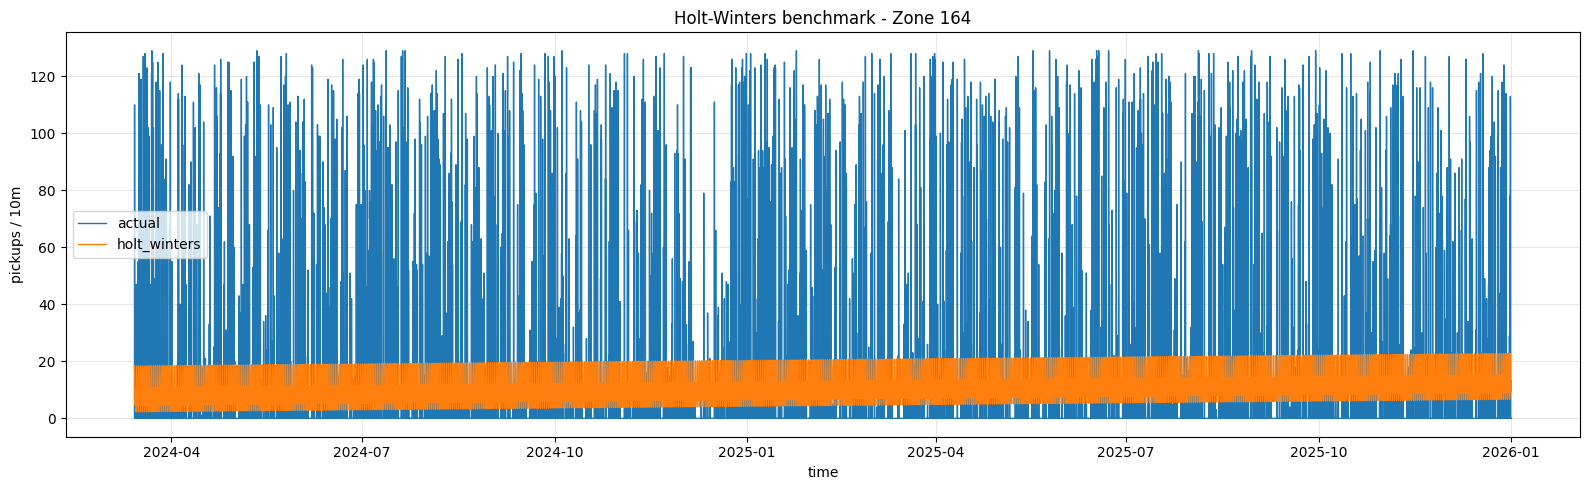

In [5]:
best_zone = int(metrics_pdf.sort_values("MAPE").iloc[0][ZONE_COL])
tmp = pred_sdf.where(F.col(ZONE_COL) == best_zone).orderBy(BIN_COL).toPandas()
tmp[BIN_COL] = pd.to_datetime(tmp[BIN_COL])


plt.figure(figsize=(16, 5))
plt.plot(tmp[BIN_COL], tmp["actual"], label="actual", linewidth=1.0)
plt.plot(tmp[BIN_COL], tmp["prediction"], label="holt_winters", linewidth=1.0)
plt.title(f"Holt-Winters benchmark - Zone {best_zone}")
plt.xlabel("time")
plt.ylabel("pickups / 10m")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [6]:
# Optional cleanup: run this when benchmark is done.
spark.catalog.clearCache()
spark.stop()
print("Holt-Winters Spark session stopped.")


Holt-Winters Spark session stopped.
